In [1]:
from utilities.data_loader import load_data

train_prices, train_dates, test_prices, test_dates = load_data("./data/BTC-Daily.csv")

In [2]:
from utilities.filters import lma_filter, ema_filter, wma, sma_filter

print(sma_filter(3))
print(sum(sma_filter(3)))

print(lma_filter(3))
print(sum(lma_filter(3)))

print(ema_filter(3, 0.5))
print(sum(ema_filter(3, 0.5)))

[0.33333333 0.33333333 0.33333333]
1.0
[0.5        0.33333333 0.16666667]
1.0
[0.57142857 0.28571429 0.14285714]
1.0


In [3]:
P = train_prices
N = 3
print(wma(P, N, sma_filter(N)))
print(wma(P, N, lma_filter(N)))
print(wma(P, N, ema_filter(N, 0.5)))


[-124.59333333  125.42666667  375.44666667 ... 7309.26       7300.67333333
 7258.04666667]
[3.43333333e-01 2.51000000e+02 3.74956667e+02 ... 7.33251667e+03
 7.28800667e+03 7.22185000e+03]
[  54.04857143  268.96        374.72571429 ... 7340.09142857 7278.32571429
 7214.20857143]


DO buy at time 92 with price 252.98
Do sell at time 123 with price 243.98
DO buy at time 181 with price 236.46
Do sell at time 185 with price 223.67
DO buy at time 201 with price 245.78
Do sell at time 260 with price 261.03
Final cash 807.0350193804247


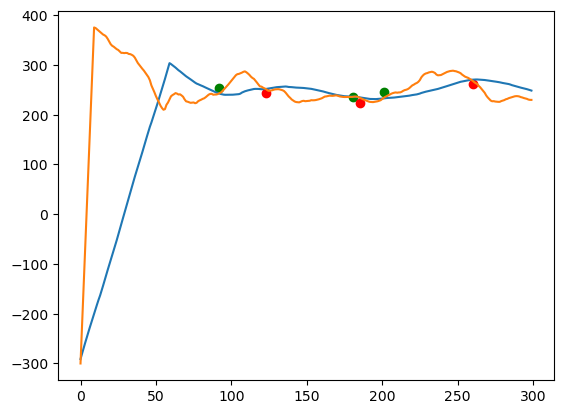

In [4]:
import matplotlib.pyplot as plt
import numpy as np
P = train_prices[:300]

Long_N = 60
Short_N = 10
long = (wma(P, Long_N, sma_filter(Long_N)))
short = (wma(P, Short_N, sma_filter(Short_N)))
diff = short - long
# print(len(diff))
# print("signs", np.sign(diff))
Sign_kernel = np.array([0.5, -0.5])
signals = (wma(np.sign(diff), 2, Sign_kernel))

# Replace longest N with 0 to invalidate trade window from padding induced trade
longest = max(Long_N, Short_N)
signals[:longest] = 0

# print("signals", signals)
# print("len signals", len(signals))
# print("signals != 0", signals[signals != 0])
cash = 1000.0 
btc_held = 0.0
fee = 0.03

for t in range(len(P)):
    if signals[t] == 1 and btc_held == 0:
        print(f"DO buy at time {t} with price {P[t]}")
        spend = cash * (1 - fee)
        btc_held = spend / P[t]
        cash = 0
        plt.plot(t, P[t], 'go')
    if signals[t] == -1 and btc_held > 0:
        print(f"Do sell at time {t} with price {P[t]}")
        gain = btc_held * P[t]
        gainminusfee = gain * (1 - fee)
        cash = gainminusfee
        btc_held = 0
        plt.plot(t, P[t], 'ro')
# If at the end still holding bitcoin, sell them
if btc_held > 0:
    print(f"Do sell at time {t} with price {P[t]}")
    gain = btc_held * P[t]
    gainminusfee = gain * (1 - fee)
    cash += gainminusfee
    plt.plot(t, P[t], 'ro')
print("Final cash", cash)


plt.plot(long)
plt.plot(short)
plt.show()


In [5]:
from optimizer.evaluator import evaluate
temp_short = np.copy(short)
temp_long = np.copy(long)
cash, buy_at, sell_at, equity_curve = evaluate(P, temp_short, temp_long)

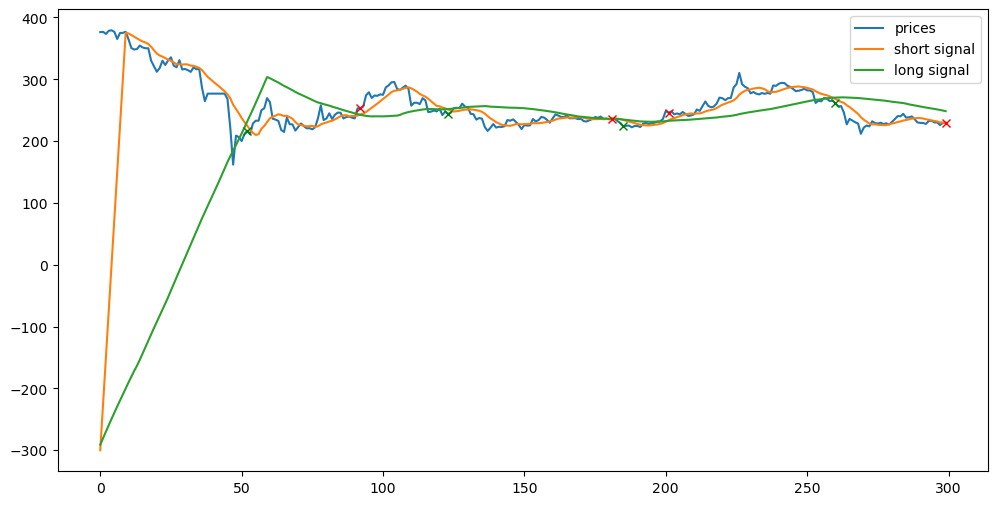

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(P, label="prices") 
ax.plot(temp_short, label = "short signal")
ax.plot(temp_long, label = "long signal")

for point in buy_at:
  ax.plot(point[0], point[1], 'gx')

for point in sell_at:
  ax.plot(point[0], point[1], 'rx')

# ax.plot(equity_curve, label = "portfolio value")
ax.legend()
plt.show()
